# Problem 2 (Regression)

- Import needed libraries
- import csv file and split it into 3 datasets [training , validation , testing]

In [1094]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("California_Houses.csv")




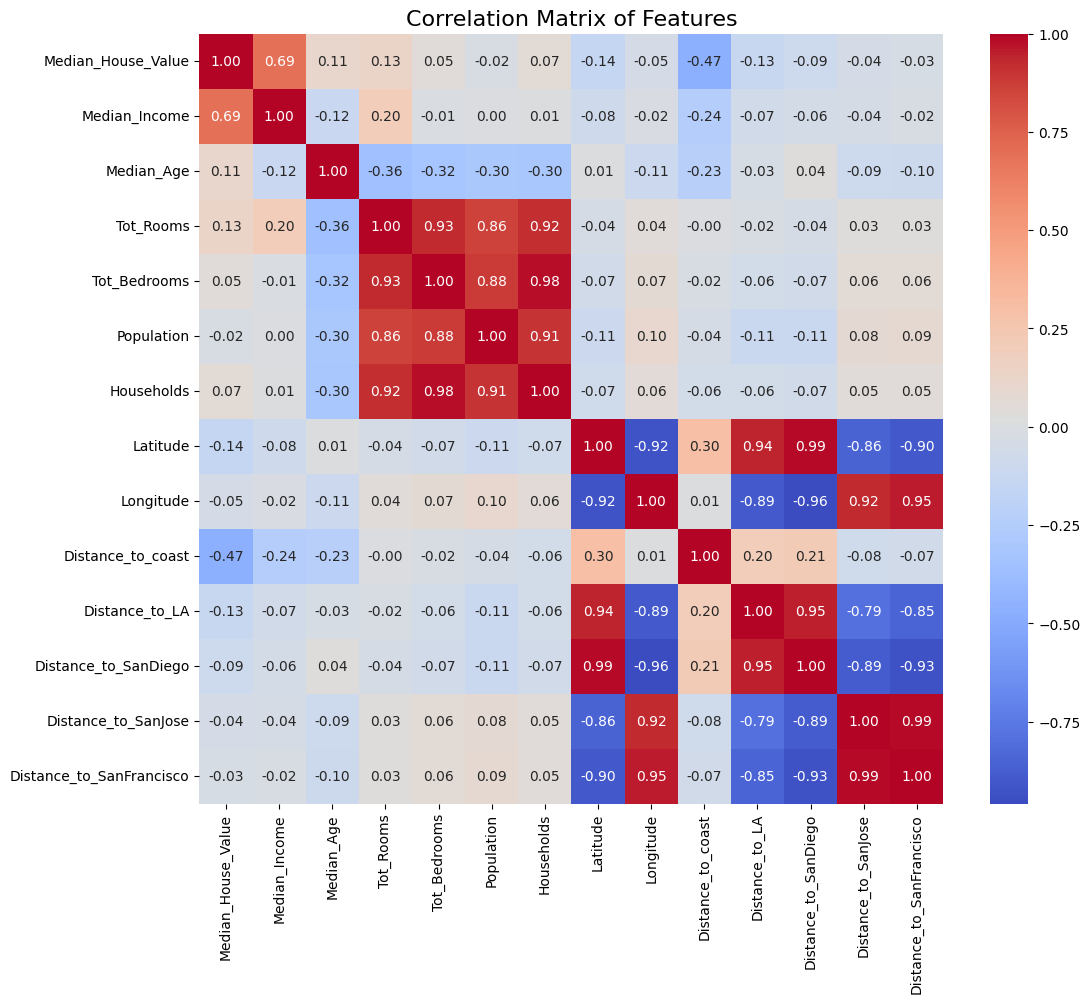

In [1095]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Calculate the correlation matrix from your DataFrame ---
correlation_matrix = df.corr()

# --- 2. Create the heatmap ---
plt.figure(figsize=(12, 10)) # You can adjust the figure size as needed
sns.heatmap(
    correlation_matrix, 
    annot=True,         # Show the correlation values on the heatmap
    fmt='.2f',          # Format the numbers to two decimal places
    cmap='coolwarm'     # Use the 'coolwarm' color map
)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

Text(0, 0.5, 'Frequency')

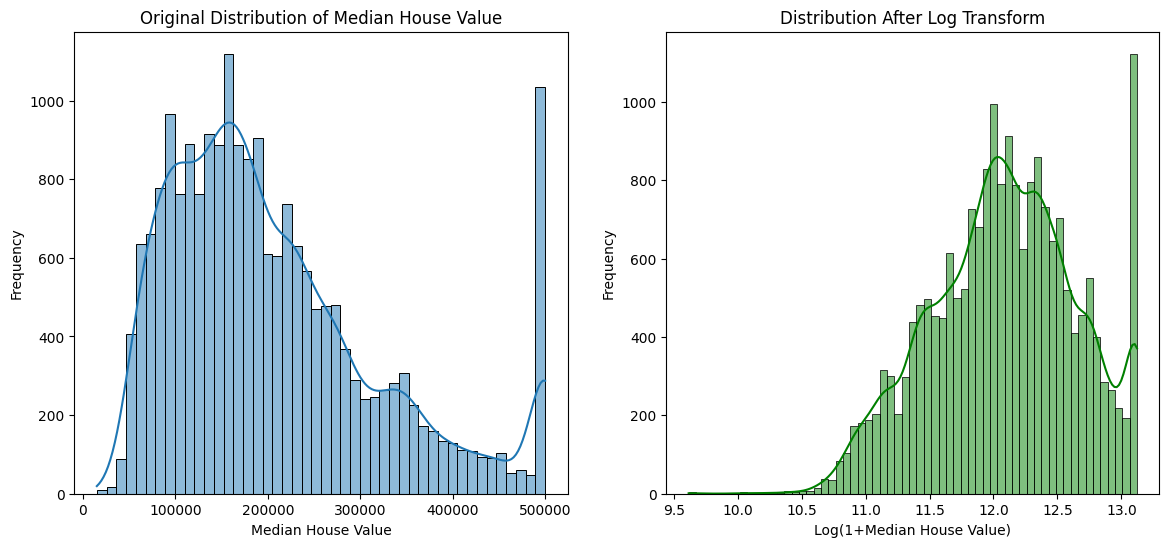

In [1096]:

# Create a figure for plotting
plt.figure(figsize=(14, 6))

# Plot the original distribution of the target variable
plt.subplot(1, 2, 1)
sns.histplot(df['Median_House_Value'], kde=True)
plt.title('Original Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

# Apply a log transform to the target variable
# We use np.log1p which calculates log(1 + x) to avoid issues with zero values
df['Median_House_Value_Log'] = np.log1p(df['Median_House_Value'])

# Plot the new distribution after log transform
plt.subplot(1, 2, 2)
sns.histplot(df['Median_House_Value_Log'], kde=True, color='green')
plt.title('Distribution After Log Transform')
plt.xlabel('Log(1+Median House Value)')
plt.ylabel('Frequency')




In [1097]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))

train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]

calculate mean squared error and mean absolute erro

In [1098]:
def mean_squared(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)


def mean_absolute(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))


Normalize datasets , X = ( X - mean ) / standard deviation

In [1099]:
means = train_df.mean(numeric_only=True)
stds = train_df.std(numeric_only=True)
train_norm = (train_df - means) / stds
val_norm = (val_df - means) / stds
test_norm = (test_df - means) / stds


Added Bias coloumn for datasets and dropped target coloumn

In [1100]:
target_col = "Median_House_Value"   

X = train_norm.drop(columns=[target_col]).to_numpy()
V = val_norm.drop(columns=[target_col]).to_numpy()
Test = test_norm.drop(columns=[target_col]).to_numpy()

xones = np.ones((X.shape[0], 1))
vones = np.ones((V.shape[0], 1))
tones = np.ones((Test.shape[0], 1))

X_with_bias = np.hstack((xones, X))
v_with_bias = np.hstack((vones, V))
Test_with_bias = np.hstack((tones, Test))

x_target= train_norm[target_col].to_numpy().reshape(-1, 1)
v_target= val_norm[target_col].to_numpy().reshape(-1, 1)
t_target= test_norm[target_col].to_numpy().reshape(-1, 1)


# Manual Implementation

Calculate weights using Linear Regression - Direct form

In [1101]:
W_lin = np.dot(np.linalg.inv(np.dot(X_with_bias.T,X_with_bias)) ,np.dot(X_with_bias.T, x_target))
print("Closed-form solution Weights:")
print(W_lin)

Closed-form solution Weights:
[[-2.40784768e-16]
 [ 1.33177124e-01]
 [ 7.43066531e-02]
 [-6.11866752e-02]
 [ 5.60736504e-02]
 [-6.91383126e-02]
 [ 6.96856452e-02]
 [-6.09600918e-01]
 [-3.33871172e-02]
 [ 1.50901509e-01]
 [ 9.13742562e-03]
 [ 6.65991198e-01]
 [ 7.01533443e-03]
 [ 9.86064653e-02]
 [ 9.15364926e-01]]


Test weights on validation dataset and calculate MSE and MAE

In [1102]:
y_pred_dir_form = np.dot(v_with_bias, W_lin)
mse_lin_manual_validation = mean_squared(v_target, y_pred_dir_form)
mae_lin_manual_validation = mean_absolute(v_target, y_pred_dir_form)
print("Mean Squared Error (Validation):", mse_lin_manual_validation)
print("Mean Absolute Error (Validation):", mae_lin_manual_validation)

Mean Squared Error (Validation): 0.07832257252541956
Mean Absolute Error (Validation): 0.2136381492980262


Calculate weights using Linear Regression - Ridge regulization with different lambdas

In [1103]:
print("\nRidge Regression with Different Lambdas:")
N = X_with_bias.shape[0]  
I = np.eye(X_with_bias.shape[1])  
lambdas = [0,0.000001,0.00001,0.0001,0.001, 0.01, 0.1, 1, 10, 100]  

results1 = []
results2 = []
for lam in lambdas:
    temp_w_Ridge = np.dot(np.linalg.inv(np.dot(X_with_bias.T ,X_with_bias) + lam * N * I),np.dot(X_with_bias.T, x_target))
    y_pred_ridge = np.dot(v_with_bias , temp_w_Ridge)
    mse = mean_squared(v_target, y_pred_ridge)
    mae = mean_absolute(v_target, y_pred_ridge)
    results1.append((lam, mse)) 
    results2.append((lam, mae))
    print(f"Lambda = {lam}  |  Validation MSE = {mse}  |  Validation MAE = {mae}")
best_lambda, best_mse = min(results1, key=lambda x: x[1])
print("\nBest Lambda:", best_lambda)
print("Lowest Validation MSE:", best_mse)
best_lambda, best_mae = min(results2, key=lambda x: x[1])
print("\nBest Lambda:", best_lambda)
print("Lowest Validation MAE:", best_mae)

W_ridge = np.dot(np.linalg.inv(np.dot(X_with_bias.T ,X_with_bias) + best_lambda * N * I),np.dot(X_with_bias.T, x_target))
mse_ridge_validation = best_mse
mae_ridge_validation = best_mae


Ridge Regression with Different Lambdas:
Lambda = 0  |  Validation MSE = 0.07832257252541956  |  Validation MAE = 0.2136381492980262
Lambda = 1e-06  |  Validation MSE = 0.0783229834725331  |  Validation MAE = 0.21363871652588612
Lambda = 1e-05  |  Validation MSE = 0.07832670754417391  |  Validation MAE = 0.21364420944193618
Lambda = 0.0001  |  Validation MSE = 0.0783661705330657  |  Validation MAE = 0.21370207705614527
Lambda = 0.001  |  Validation MSE = 0.07881949831155163  |  Validation MAE = 0.2142043077644963
Lambda = 0.01  |  Validation MSE = 0.08047990098498928  |  Validation MAE = 0.21546274234492133
Lambda = 0.1  |  Validation MSE = 0.09120591752270586  |  Validation MAE = 0.22360658440879638
Lambda = 1  |  Validation MSE = 0.2384363846300218  |  Validation MAE = 0.3607563301236462
Lambda = 10  |  Validation MSE = 0.7317023642360704  |  Validation MAE = 0.6750932821948713
Lambda = 100  |  Validation MSE = 0.9528931954314575  |  Validation MAE = 0.7741907289946244

Best Lambda:

graph for ridge regression

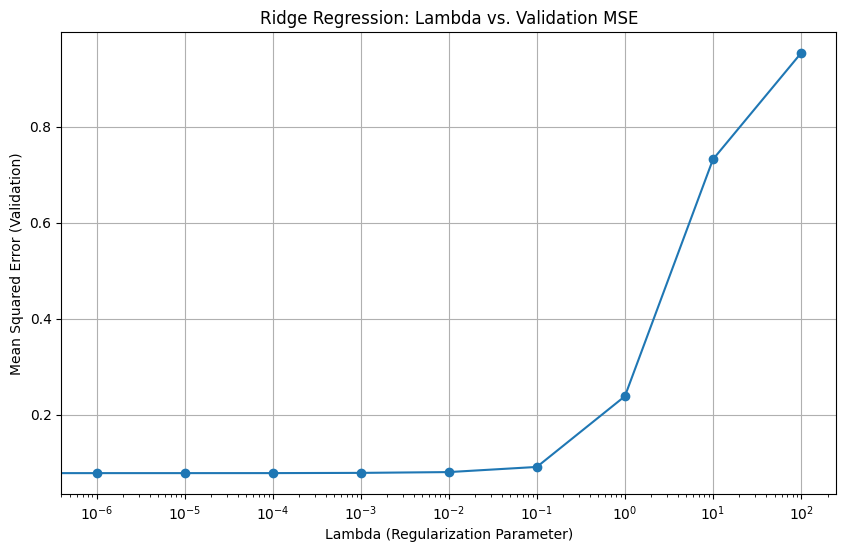

In [1104]:
lambdas = [lam for lam, _ in results1]
mses = [mse for _, mse in results1]
plt.figure(figsize=(10, 6))
plt.plot(lambdas, mses, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (Regularization Parameter)')
plt.ylabel('Mean Squared Error (Validation)')
plt.title('Ridge Regression: Lambda vs. Validation MSE')
plt.grid(True)
plt.show()

Calculate weights using Linear Regression - Gradient Descent

In [1105]:
w_gd = np.zeros((X_with_bias.shape[1],1))
learning_rate = 0.01
iterations = 1000
tolerance = 1e-6
prev_mse = float('inf')

for i in range(10000):
    y_pred_training_GD = np.dot(X_with_bias, w_gd)
    errors =  y_pred_training_GD - x_target
    gradients = (1/N) * np.dot(X_with_bias.T, errors)
    w_gd -= learning_rate * gradients

    current_mse = mean_squared(x_target, y_pred_training_GD)
    if abs(prev_mse - current_mse) < tolerance:
        print(f"Converged after {i} iterations.")
        break
    prev_mse = current_mse

print("Weights from Gradient Descent:\n", w_gd)
mse_lin_manual_gd_validation = current_mse

y_pred_validation_GD = np.dot(v_with_bias, w_gd)
mae_lin_manual_gd_validation = mean_absolute(v_target, y_pred_validation_GD)
print("Final MSE from Gradient Descent:", mse_lin_manual_gd_validation)
print("Final MAE from Gradient Descent:", mae_lin_manual_gd_validation)

Converged after 1548 iterations.
Weights from Gradient Descent:
 [[ 4.91414666e-16]
 [ 1.35086729e-01]
 [ 7.28687769e-02]
 [-2.80656520e-02]
 [ 6.26541659e-02]
 [-9.09374975e-02]
 [ 5.13406065e-02]
 [-3.47874836e-02]
 [-4.87213891e-02]
 [ 9.63395314e-02]
 [ 7.96021173e-03]
 [ 2.09690514e-02]
 [ 1.40090347e-02]
 [ 1.87377213e-02]
 [ 8.98531337e-01]]
Final MSE from Gradient Descent: 0.08055401806391178
Final MAE from Gradient Descent: 0.21702899255743024


Calculate weights using Linear Regression - Ridge Regularization and Gradient Descent

In [1106]:
N = X_with_bias.shape[0]
d = X_with_bias.shape[1]

learning_rate = 0.01
iterations = 10000
tolerance = 1e-6

lambdas = [0, 0.001, 0.01, 0.1, 1, 10]
results = []
best_w = None

for lam in lambdas:
    w = np.zeros((d, 1))
    prev_mse = float('inf')

    for i in range(iterations):
        y_pred_training_ridge_GD = np.dot(v_with_bias, w)
        errors = y_pred_training_ridge_GD - v_target
        gradients = (1/N) * (np.dot(v_with_bias.T, errors) + lam * w)
        w -= learning_rate * gradients
        current_mse = mean_squared(v_target, y_pred_training_ridge_GD)
        if abs(prev_mse - current_mse) < tolerance:
            break
        prev_mse = current_mse

    y_pred_validation_ridge_GD = np.dot(v_with_bias, w)
    mae = mean_absolute(v_target, y_pred_validation_ridge_GD)
    results.append((lam, current_mse, mae, w))
    print(f"Lambda = {lam:<6} | MSE = {current_mse:.6f} | MAE = {mae:.6f}")

best_lambda, best_mse, best_mae, w_ridge_gd = min(results, key=lambda x: x[1])

print("\nBest Lambda:", best_lambda)
print("Lowest Validation MSE:", best_mse)
print("Corresponding MAE:", best_mae)
print("Best Weights:\n", w_ridge_gd)

mse_ridge_gd_validation = best_mse
mae_ridge_gd_validation = best_mae


Lambda = 0      | MSE = 0.082086 | MAE = 0.216642
Lambda = 0.001  | MSE = 0.082086 | MAE = 0.216642
Lambda = 0.01   | MSE = 0.082086 | MAE = 0.216642
Lambda = 0.1    | MSE = 0.082087 | MAE = 0.216642
Lambda = 1      | MSE = 0.082098 | MAE = 0.216643
Lambda = 10     | MSE = 0.082212 | MAE = 0.216661

Best Lambda: 0
Lowest Validation MSE: 0.08208603115599361
Corresponding MAE: 0.21664180480775352
Best Weights:
 [[-6.82732237e-05]
 [ 1.56187213e-01]
 [ 7.16907735e-02]
 [ 1.92374874e-03]
 [ 7.02392723e-02]
 [-1.22238630e-01]
 [ 3.74576624e-02]
 [-1.96567723e-02]
 [-2.52976414e-02]
 [ 6.66722050e-02]
 [ 3.61790123e-03]
 [ 2.63614938e-02]
 [ 2.01910151e-02]
 [ 1.66560174e-02]
 [ 8.47206939e-01]]


# Scikit-Learn Implementation

Calculate weights using Linear Regression

In [1107]:
lin_model = LinearRegression()
lin_model.fit(X_with_bias, x_target)
y_pred_lin = lin_model.predict(v_with_bias)

mse_lin_scikit_validation = mean_squared_error(v_target, y_pred_lin)
mae_lin_scikit_validation = mean_absolute_error(v_target, y_pred_lin)

print("Linear Regression:")
print(f"  MSE = {mse_lin_scikit_validation}")
print(f"  MAE = {mae_lin_scikit_validation}")
print("-" * 40)

Linear Regression:
  MSE = 0.0783225725254196
  MAE = 0.21363814929802605
----------------------------------------


Calculate weights using Linear Regression - Lasso regulization

In [1108]:
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_with_bias, x_target)
y_pred_lasso = lasso_model.predict(v_with_bias)

mse_lasso_validation = mean_squared_error(v_target, y_pred_lasso)
mae_lasso_validation = mean_absolute_error(v_target, y_pred_lasso)

print("Lasso Regression:")
print(f"  MSE = {mse_lasso_validation}")
print(f"  MAE = {mae_lasso_validation}")
print("-" * 40)

Lasso Regression:
  MSE = 0.07987174686030575
  MAE = 0.21552922634920527
----------------------------------------


Calculate weights using Linear Regression - Ridge regulization

In [1109]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_with_bias, x_target)
y_pred_ridge = ridge_model.predict(v_with_bias)

mse_ridge_scikit_validation = mean_squared_error(v_target, y_pred_ridge)
mae_ridge_scikit_validation = mean_absolute_error(v_target, y_pred_ridge)

print("Ridge Regression:")
print(f"  MSE = {mse_ridge_scikit_validation}")
print(f"  MAE = {mae_ridge_scikit_validation}")
print("-" * 40)

Ridge Regression:
  MSE = 0.07835225950295104
  MAE = 0.21368285800112316
----------------------------------------


# Final Results Comparison (validtion dataset)

In [1110]:
print("******Linear Regression******")
print("manual mse:", mse_lin_manual_validation)
print("manual mae:", mae_lin_manual_validation)
print("scikit mse:", mse_lin_scikit_validation)
print("scikit mae:", mae_lin_scikit_validation)
print("-" * 40)
print()

print("******Linear Regression (Gradient Descent)******")
print("manual mse (gd):", mse_lin_manual_gd_validation)
print("manual mae (gd):", mae_lin_manual_gd_validation)
print("-" * 40)
print()

print("******Ridge Regression******")
print("manual mse:", mse_ridge_validation)
print("manual mae:", mae_ridge_validation)
print("manual with gradient descent mse:", mse_ridge_gd_validation)
print("manual with gradient descent mae:", mae_ridge_gd_validation)
print("scikit mse:", mse_ridge_scikit_validation)
print("scikit mae:", mae_ridge_scikit_validation)
print("-" * 40)
print()

print("******Lasso Regression******")
print("scikit mse:", mse_lasso_validation)
print("scikit mae:", mae_lasso_validation)

******Linear Regression******
manual mse: 0.07832257252541956
manual mae: 0.2136381492980262
scikit mse: 0.0783225725254196
scikit mae: 0.21363814929802605
----------------------------------------

******Linear Regression (Gradient Descent)******
manual mse (gd): 0.08055401806391178
manual mae (gd): 0.21702899255743024
----------------------------------------

******Ridge Regression******
manual mse: 0.07832257252541956
manual mae: 0.2136381492980262
manual with gradient descent mse: 0.08208603115599361
manual with gradient descent mae: 0.21664180480775352
scikit mse: 0.07835225950295104
scikit mae: 0.21368285800112316
----------------------------------------

******Lasso Regression******
scikit mse: 0.07987174686030575
scikit mae: 0.21552922634920527


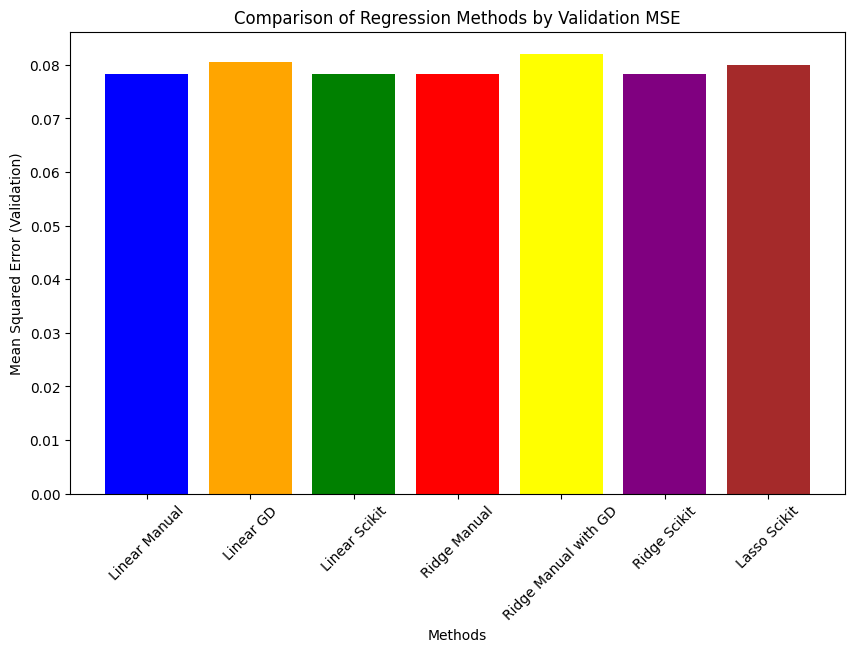

In [1111]:
# graph for all methods on validation set
methods = ['Linear Manual', 'Linear GD', 'Linear Scikit', 'Ridge Manual','Ridge Manual with GD','Ridge Scikit', 'Lasso Scikit']
mses = [mse_lin_manual_validation, mse_lin_manual_gd_validation, mse_lin_scikit_validation, mse_ridge_validation, mse_ridge_gd_validation, mse_ridge_scikit_validation, mse_lasso_validation]
plt.figure(figsize=(10, 6))
plt.bar(methods, mses, color=['blue', 'orange', 'green', 'red', 'yellow','purple', 'brown'])
plt.xlabel('Methods')
plt.ylabel('Mean Squared Error (Validation)')
plt.title('Comparison of Regression Methods by Validation MSE')
plt.xticks(rotation=45)
plt.show()

# applying trained models on test dataset & calculating error

In [1112]:
print("******Linear Regression******")
prediction_lin = np.dot(Test_with_bias, W_lin)
mse_lin_manual_test = mean_squared(t_target, prediction_lin)
mae_lin_manual_test = mean_absolute(t_target, prediction_lin)
print(f"Manual Linear Regression on Test Set  |  Test MSE = {mse_lin_manual_test}  |  Test MAE = {mae_lin_manual_test}")

prediction_lin_scikit = lin_model.predict(Test_with_bias)
mse_lin_scikit_validation = mean_squared_error(t_target, prediction_lin_scikit)
mae_lin_scikit_validation = mean_absolute_error(t_target, prediction_lin_scikit)
print(f"Scikit-learn Linear Regression on Test Set  |  Test MSE = {mse_lin_scikit_validation}  |  Test MAE = {mae_lin_scikit_validation}")
print()

print("******Linear Regression (Gradient Descent)******")
prediction_gd = np.dot(Test_with_bias, w_gd)
mse_gd_test = mean_squared(t_target, prediction_gd)
mae_gd_test = mean_absolute(t_target, prediction_gd)
print(f"Manual Linear Regression (GD) on Test Set  |  Test MSE = {mse_gd_test}  |  Test MAE = {mae_gd_test}")
print()

print("******Ridge Regression******")
prediction_ridge = np.dot(Test_with_bias , W_ridge)
mse = mean_squared(t_target, prediction_ridge)
mae = mean_absolute(t_target, prediction_ridge)
print(f"Manual Ridge Regression on Test Set  |  Test MSE = {mse}  |  Test MAE = {mae}")

prediction_ridge_gd = np.dot(Test_with_bias, w_ridge_gd)
mse_ridge_gd_test = mean_squared(t_target, prediction_ridge_gd)
mae_ridge_gd_test = mean_absolute(t_target, prediction_ridge_gd)
print(f"Manual Ridge Regression (GD) on Test Set  |  Test MSE = {mse_ridge_gd_test}  |  Test MAE = {mae_ridge_gd_test}")

prediction_ridge_scikit = ridge_model.predict(Test_with_bias)
mse_ridge_scikit_validation = mean_squared_error(t_target, prediction_ridge_scikit)
mae_ridge_scikit_validation = mean_absolute_error(t_target, prediction_ridge_scikit)
print(f"Scikit-learn Ridge Regression on Test Set  |  Test MSE = {mse_ridge_scikit_validation}  |  Test MAE = {mae_ridge_scikit_validation}")

print()

print("******Lasso Regression******")
prediction_lasso = lasso_model.predict(Test_with_bias)
mse_lasso_test = mean_squared_error(t_target, prediction_lasso)
mae_lasso_test = mean_absolute_error(t_target, prediction_lasso)
print(f"Scikit-learn Lasso Regression on Test Set  |  Test MSE = {mse_lasso_test}  |  Test MAE = {mae_lasso_test}")

******Linear Regression******
Manual Linear Regression on Test Set  |  Test MSE = 0.08348359448266321  |  Test MAE = 0.2194138730092479
Scikit-learn Linear Regression on Test Set  |  Test MSE = 0.08348359448266322  |  Test MAE = 0.21941387300924775

******Linear Regression (Gradient Descent)******
Manual Linear Regression (GD) on Test Set  |  Test MSE = 0.0865060532624837  |  Test MAE = 0.22165235661199256

******Ridge Regression******
Manual Ridge Regression on Test Set  |  Test MSE = 0.08348359448266321  |  Test MAE = 0.2194138730092479
Manual Ridge Regression (GD) on Test Set  |  Test MSE = 0.09019219524477004  |  Test MAE = 0.22336666395609875
Scikit-learn Ridge Regression on Test Set  |  Test MSE = 0.08347748955532666  |  Test MAE = 0.219411787606164

******Lasso Regression******
Scikit-learn Lasso Regression on Test Set  |  Test MSE = 0.08426234287069817  |  Test MAE = 0.22035400406304623


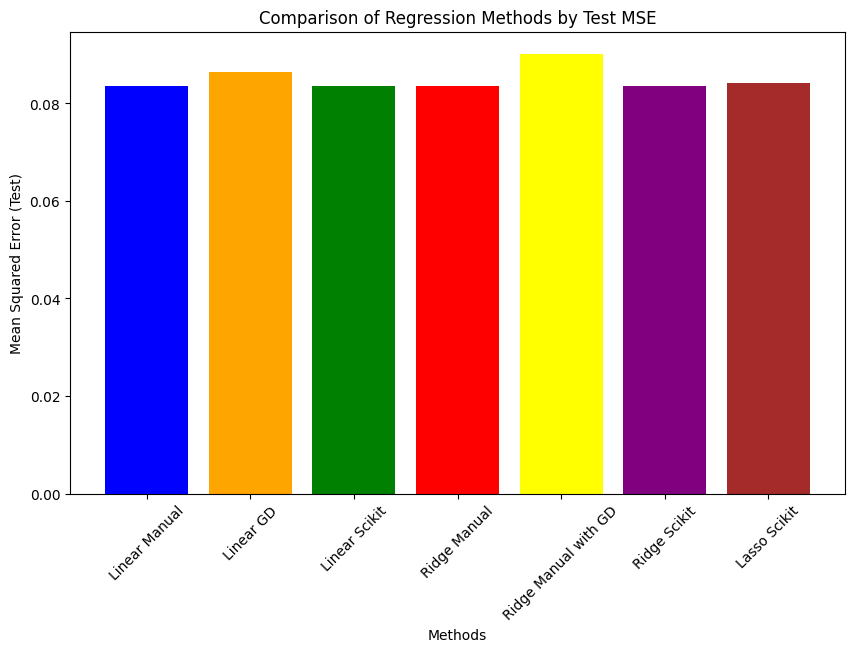

In [1113]:
# graph for all methods on test set
methods = ['Linear Manual', 'Linear GD', 'Linear Scikit', 'Ridge Manual','Ridge Manual with GD','Ridge Scikit', 'Lasso Scikit']
mses = [mse_lin_manual_test, mse_gd_test, mse_lin_scikit_validation, mse, mse_ridge_gd_test, mse_ridge_scikit_validation, mse_lasso_test]
plt.figure(figsize=(10, 6))
plt.bar(methods, mses, color=['blue', 'orange', 'green', 'red', 'yellow','purple', 'brown'])
plt.xlabel('Methods')
plt.ylabel('Mean Squared Error (Test)')
plt.title('Comparison of Regression Methods by Test MSE')
plt.xticks(rotation=45)
plt.show()